In [0]:
df = spark.read \
    .option("header","true") \
    .option("inferSchema","true") \
    .csv("/Volumes/project/weather/weat/*.csv")

In [0]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

features = [
    "temperature_2m",
    "relative_humidity_2m",
    "rain",
    "precipitation",
    "wind_speed_10m",
    "surface_pressure",
    "cloud_cover"
]

assembler = VectorAssembler(inputCols=features, outputCol="features")
vector_df = assembler.transform(df).select("features")

corr_matrix = Correlation.corr(vector_df, "features", "pearson").collect()[0][0]

import pandas as pd

corr_df = pd.DataFrame(corr_matrix.toArray(), index=features, columns=features)
display(corr_df)

temperature_2m,relative_humidity_2m,rain,precipitation,wind_speed_10m,surface_pressure,cloud_cover
1.0,-0.5468154379635197,0.0017965989916240961,0.0017965989916240961,0.19432050191952885,-0.1243182284242498,0.06557249762002125
-0.5468154379635197,1.0,0.18007447416213165,0.18007447416213165,-0.08068667383695814,0.13651897459260634,0.42195749215521416
0.0017965989916240961,0.18007447416213165,1.0,1.0000000000000002,0.060016089070997654,-0.006124227044314586,0.29139166062294214
0.0017965989916240961,0.18007447416213165,1.0000000000000002,1.0,0.060016089070997654,-0.006124227044314586,0.29139166062294214
0.19432050191952885,-0.08068667383695814,0.060016089070997654,0.060016089070997654,1.0,-0.146724881782215,0.23269734253833083
-0.1243182284242498,0.13651897459260634,-0.006124227044314586,-0.006124227044314586,-0.146724881782215,1.0,-0.20809564653110343
0.06557249762002125,0.42195749215521416,0.29139166062294214,0.29139166062294214,0.23269734253833083,-0.20809564653110343,1.0


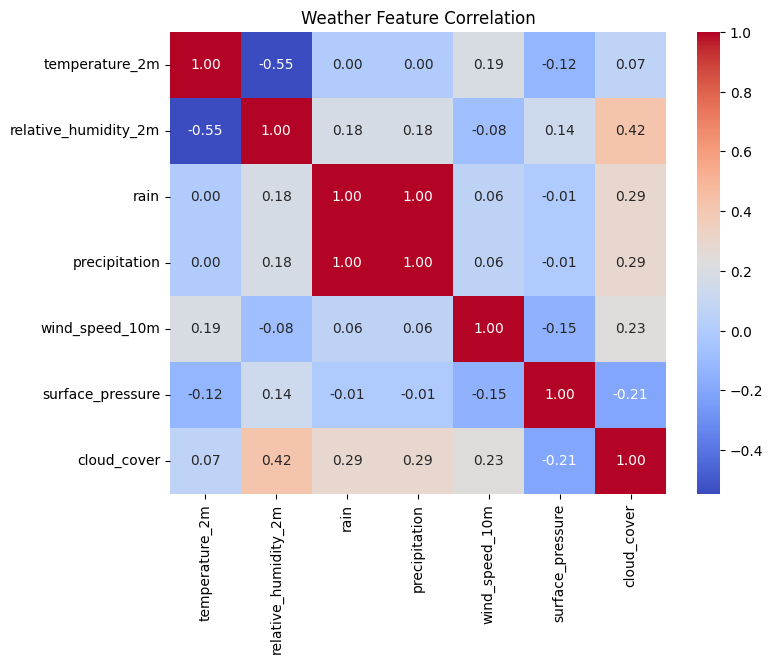

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Weather Feature Correlation")
plt.show()

In [0]:
weather_df = df.select(
    "temperature_2m",
    "relative_humidity_2m",
    "rain",
    "precipitation",
    "wind_speed_10m",
    "surface_pressure",
    "cloud_cover"
)

In [0]:
pdf = weather_df.toPandas()

corr = pdf.corr()

display(corr)

temperature_2m,relative_humidity_2m,rain,precipitation,wind_speed_10m,surface_pressure,cloud_cover
1.0,-0.5468154379635731,0.001796598991625022,0.001796598991625022,0.19432050191953884,-0.12431822842431467,0.06557249762003439
-0.5468154379635731,1.0,0.18007447416228306,0.18007447416228306,-0.08068667383696458,0.13651897459276802,0.42195749215510975
0.001796598991625022,0.18007447416228306,1.0,1.0,0.060016089071043735,-0.00612422704434004,0.2913916606232257
0.001796598991625022,0.18007447416228306,1.0,1.0,0.060016089071043735,-0.00612422704434004,0.2913916606232257
0.19432050191953884,-0.08068667383696458,0.060016089071043735,0.060016089071043735,1.0,-0.14672488178224033,0.23269734253825425
-0.12431822842431467,0.13651897459276802,-0.00612422704434004,-0.00612422704434004,-0.14672488178224033,1.0,-0.20809564653100404
0.06557249762003439,0.42195749215510975,0.2913916606232257,0.2913916606232257,0.23269734253825425,-0.20809564653100404,1.0


In [0]:
%pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 25.8 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif = pd.DataFrame()
vif["Feature"] = pdf.columns
vif["VIF"] = [variance_inflation_factor(pdf.values, i)
              for i in range(pdf.shape[1])]

display(vif)

/local_disk0/.ephemeral_nfs/envs/pythonEnv-2ec666c7-efc9-4fe9-8c05-8265a0096160/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Feature,VIF
temperature_2m,36.94254109007112
relative_humidity_2m,20.467469169358207
rain,Infinity
precipitation,Infinity
wind_speed_10m,5.020579971095199
surface_pressure,78.41554881529757
cloud_cover,3.339174790001447


In [0]:
corr.unstack().sort_values(ascending=False)



temperature_2m        temperature_2m          1.000000
relative_humidity_2m  relative_humidity_2m    1.000000
surface_pressure      surface_pressure        1.000000
wind_speed_10m        wind_speed_10m          1.000000
precipitation         rain                    1.000000
rain                  precipitation           1.000000
                      rain                    1.000000
precipitation         precipitation           1.000000
cloud_cover           cloud_cover             1.000000
relative_humidity_2m  cloud_cover             0.421957
cloud_cover           relative_humidity_2m    0.421957
rain                  cloud_cover             0.291392
cloud_cover           precipitation           0.291392
                      rain                    0.291392
precipitation         cloud_cover             0.291392
cloud_cover           wind_speed_10m          0.232697
wind_speed_10m        cloud_cover             0.232697
temperature_2m        wind_speed_10m          0.194321
wind_speed